In [1]:
from __future__ import annotations

import json
import math
import os
import re
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageEnhance, ImageFilter, ImageOps


In [2]:
from __future__ import annotations

import json
import math
import os
import re
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageEnhance, ImageFilter, ImageOps


EXPIRY_KEYWORDS = (
    "賞味期限",
    "消費期限",
    "best before",
    "use by",
    "expiration",
    "expiry",
    "expires",
)

DATE_PATTERNS = (
    re.compile(r"\b(20\d{2})[./-](\d{1,2})[./-](\d{1,2})\b"),
    re.compile(r"\b(\d{2})[./-](\d{1,2})[./-](\d{1,2})\b"),
    re.compile(r"(20\d{2})年(\d{1,2})月(\d{1,2})日"),
    re.compile(r"(\d{1,2})月(\d{1,2})日"),
)


def ensure_rgb(image: Image.Image) -> Image.Image:
    if not isinstance(image, Image.Image):
        raise TypeError("image must be a PIL.Image.Image instance")
    return image.convert("RGB")


def preprocess_image(
    image: Image.Image,
    max_side: int = 1280,
    contrast: float = 1.15,
    sharpness: float = 1.2,
) -> Image.Image:
    image = ensure_rgb(image).copy()
    image.thumbnail((max_side, max_side))
    image = ImageOps.autocontrast(image)
    image = image.filter(ImageFilter.MedianFilter(size=3))
    image = ImageEnhance.Contrast(image).enhance(contrast)
    image = ImageEnhance.Sharpness(image).enhance(sharpness)
    return image


def save_pil_image(image: Image.Image, path: str | Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ensure_rgb(image).save(path)
    return path


def _to_float_list(values: Any) -> list[float]:
    if hasattr(values, "detach"):
        values = values.detach().cpu().numpy()
    elif hasattr(values, "cpu"):
        values = values.cpu().numpy()
    elif isinstance(values, np.ndarray):
        pass
    else:
        values = np.asarray(values)
    return values.astype(float).tolist()


def build_yolo_detections(result: Any) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    boxes = getattr(result, "boxes", None)
    if boxes is None or len(boxes) == 0:
        return pd.DataFrame(
            columns=[
                "detection_id",
                "label",
                "confidence",
                "x1",
                "y1",
                "x2",
                "y2",
                "width",
                "height",
                "center_x",
                "center_y",
            ]
        )

    xyxy = _to_float_list(boxes.xyxy)
    conf = _to_float_list(boxes.conf)
    cls = [int(value) for value in _to_float_list(boxes.cls)]
    names = getattr(result, "names", {})

    for index, (bbox, score, class_id) in enumerate(zip(xyxy, conf, cls)):
        x1, y1, x2, y2 = bbox
        rows.append(
            {
                "detection_id": index,
                "label": names.get(class_id, str(class_id)),
                "confidence": round(float(score), 4),
                "class_id": class_id,
                "x1": round(float(x1), 2),
                "y1": round(float(y1), 2),
                "x2": round(float(x2), 2),
                "y2": round(float(y2), 2),
                "width": round(float(x2 - x1), 2),
                "height": round(float(y2 - y1), 2),
                "center_x": round(float((x1 + x2) / 2), 2),
                "center_y": round(float((y1 + y2) / 2), 2),
            }
        )

    return pd.DataFrame(rows)


def annotate_yolo_detections(image: Image.Image, detections_df: pd.DataFrame) -> Image.Image:
    canvas = ensure_rgb(image).copy()
    draw = ImageDraw.Draw(canvas)

    for row in detections_df.to_dict(orient="records"):
        bbox = (row["x1"], row["y1"], row["x2"], row["y2"])
        label = f'{row["label"]} {row["confidence"]:.2f}'
        draw.rectangle(bbox, outline=(255, 120, 0), width=4)
        draw.text((row["x1"], max(0, row["y1"] - 16)), label, fill=(255, 120, 0))

    return canvas


def _load_json(path: str | Path) -> Any:
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def run_text_detection(detection: Any, image_path: str | Path, save_dir: str | Path) -> list[dict[str, Any]]:
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    outputs = detection.predict(input=str(image_path), batch_size=1)
    payloads: list[dict[str, Any]] = []

    for index, result in enumerate(outputs):
        json_path = save_dir / f"det_result_{index}.json"
        image_output_path = save_dir / f"det_result_{index}.jpg"
        result.save_to_json(save_path=str(json_path))
        result.save_to_img(save_path=str(image_output_path))
        payloads.append(
            {
                "json_path": str(json_path),
                "image_path": str(image_output_path),
                "data": _load_json(json_path),
            }
        )

    return payloads


def _normalize_polygon(poly: Any) -> list[list[float]]:
    if isinstance(poly, dict) and "points" in poly:
        poly = poly["points"]

    if not isinstance(poly, (list, tuple)):
        raise TypeError("polygon must be a list or tuple")

    if len(poly) == 4 and all(isinstance(value, (int, float)) for value in poly):
        x1, y1, x2, y2 = poly
        return [[float(x1), float(y1)], [float(x2), float(y1)], [float(x2), float(y2)], [float(x1), float(y2)]]

    normalized: list[list[float]] = []
    for point in poly:
        if isinstance(point, (list, tuple)) and len(point) >= 2:
            normalized.append([float(point[0]), float(point[1])])

    if not normalized:
        raise ValueError("polygon does not contain usable points")
    return normalized


def extract_polygons(det_data: Any) -> list[list[list[float]]]:
    if isinstance(det_data, dict):
        for key in ("dt_polys", "polys", "boxes"):
            if key in det_data:
                return [_normalize_polygon(poly) for poly in det_data[key]]

    if isinstance(det_data, list):
        polygons: list[list[list[float]]] = []
        for item in det_data:
            if isinstance(item, dict):
                for key in ("dt_polys", "polys", "boxes"):
                    if key in item:
                        polygons.extend(_normalize_polygon(poly) for poly in item[key])
        if polygons:
            return polygons

    raise ValueError("No OCR polygons were found in the detection output")


def polygon_to_bbox(poly: Iterable[Iterable[float]]) -> tuple[float, float, float, float]:
    xs = [float(point[0]) for point in poly]
    ys = [float(point[1]) for point in poly]
    return min(xs), min(ys), max(xs), max(ys)


def crop_from_polygon(image: Image.Image, poly: Iterable[Iterable[float]]) -> Image.Image | None:
    left, top, right, bottom = polygon_to_bbox(poly)
    left = max(0, int(left))
    top = max(0, int(top))
    right = min(image.width, int(right))
    bottom = min(image.height, int(bottom))

    if right <= left or bottom <= top:
        return None

    return ensure_rgb(image).crop((left, top, right, bottom))


def _extract_recognition_payload(rec_output: Any) -> tuple[str, float]:
    text = ""
    score = 0.0

    if isinstance(rec_output, dict):
        text = str(rec_output.get("rec_text", ""))
        score = float(rec_output.get("rec_score", 0.0) or 0.0)
        return text, score

    if isinstance(rec_output, list) and rec_output:
        candidate = rec_output[0]
        if isinstance(candidate, dict):
            text = str(candidate.get("rec_text", ""))
            score = float(candidate.get("rec_score", 0.0) or 0.0)
            return text, score

    return text, score


def find_date_candidates(text: str) -> list[str]:
    values: list[str] = []
    for pattern in DATE_PATTERNS:
        values.extend(match.group(0) for match in pattern.finditer(text))
    return list(dict.fromkeys(values))


def normalize_date_token(text: str, fallback_year: int | None = None) -> str | None:
    for pattern in DATE_PATTERNS:
        match = pattern.search(text)
        if not match:
            continue

        groups = match.groups()
        if "年" in match.group(0):
            year, month, day = int(groups[0]), int(groups[1]), int(groups[2])
            return f"{year:04d}-{month:02d}-{day:02d}"

        if len(groups) == 3:
            year = int(groups[0])
            month = int(groups[1])
            day = int(groups[2])
            if year < 100:
                year += 2000
            return f"{year:04d}-{month:02d}-{day:02d}"

        if len(groups) == 2 and fallback_year is not None:
            month = int(groups[0])
            day = int(groups[1])
            return f"{fallback_year:04d}-{month:02d}-{day:02d}"

    return None


def expiry_signal_strength(text: str) -> int:
    text_lower = text.lower()
    has_keyword = any(keyword in text_lower for keyword in EXPIRY_KEYWORDS)
    has_date = bool(find_date_candidates(text))
    if has_keyword and has_date:
        return 2
    if has_keyword or has_date:
        return 1
    return 0


def run_text_recognition(
    recognition: Any,
    image: Image.Image,
    polygons: list[list[list[float]]],
    save_dir: str | Path,
) -> list[dict[str, Any]]:
    save_dir = Path(save_dir)
    crop_dir = save_dir / "crops"
    json_dir = save_dir / "recognition_json"
    crop_dir.mkdir(parents=True, exist_ok=True)
    json_dir.mkdir(parents=True, exist_ok=True)

    results: list[dict[str, Any]] = []
    fallback_year = datetime.now(tz=timezone.utc).year

    for index, poly in enumerate(polygons):
        crop_image = crop_from_polygon(image, poly)
        if crop_image is None:
            continue

        crop_path = crop_dir / f"crop_{index}.png"
        json_path = json_dir / f"rec_{index}.json"
        crop_image.save(crop_path)

        rec_text = ""
        rec_score = 0.0
        rec_outputs = recognition.predict(input=str(crop_path), batch_size=1)
        for result in rec_outputs:
            result.save_to_json(save_path=str(json_path))
            rec_payload = _load_json(json_path)
            rec_text, rec_score = _extract_recognition_payload(rec_payload)

        bbox = polygon_to_bbox(poly)
        results.append(
            {
                "ocr_id": index,
                "polygon": poly,
                "crop_path": str(crop_path),
                "rec_text": rec_text,
                "rec_score": round(float(rec_score), 4),
                "date_candidates": find_date_candidates(rec_text),
                "normalized_expiry_date": normalize_date_token(rec_text, fallback_year=fallback_year),
                "expiry_signal_strength": expiry_signal_strength(rec_text),
                "bbox_x1": round(float(bbox[0]), 2),
                "bbox_y1": round(float(bbox[1]), 2),
                "bbox_x2": round(float(bbox[2]), 2),
                "bbox_y2": round(float(bbox[3]), 2),
            }
        )

    return results


def run_expiry_ocr_pipeline(
    detection: Any,
    recognition: Any,
    image: Image.Image,
    image_path: str | Path,
    save_dir: str | Path,
) -> tuple[pd.DataFrame, list[dict[str, Any]]]:
    save_dir = Path(save_dir)
    detection_payloads = run_text_detection(detection, image_path=image_path, save_dir=save_dir / "detection")

    polygons: list[list[list[float]]] = []
    for payload in detection_payloads:
        polygons.extend(extract_polygons(payload["data"]))

    recognition_results = run_text_recognition(
        recognition=recognition,
        image=image,
        polygons=polygons,
        save_dir=save_dir / "recognition",
    )
    return build_ocr_dataframe(recognition_results), detection_payloads


def build_ocr_dataframe(recognition_results: list[dict[str, Any]]) -> pd.DataFrame:
    if not recognition_results:
        return pd.DataFrame(
            columns=[
                "ocr_id",
                "rec_text",
                "rec_score",
                "date_candidates",
                "normalized_expiry_date",
                "expiry_signal_strength",
                "bbox_x1",
                "bbox_y1",
                "bbox_x2",
                "bbox_y2",
            ]
        )
    return pd.DataFrame(recognition_results)


def annotate_ocr_candidates(image: Image.Image, ocr_df: pd.DataFrame) -> Image.Image:
    canvas = ensure_rgb(image).copy()
    draw = ImageDraw.Draw(canvas)

    for row in ocr_df.to_dict(orient="records"):
        bbox = (row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"])
        color = (220, 20, 60) if row["expiry_signal_strength"] > 0 else (0, 170, 255)
        label = row["rec_text"][:32]
        draw.rectangle(bbox, outline=color, width=3)
        draw.text((row["bbox_x1"], max(0, row["bbox_y1"] - 16)), label, fill=color)

    return canvas


def _intersection_area(box_a: tuple[float, float, float, float], box_b: tuple[float, float, float, float]) -> float:
    left = max(box_a[0], box_b[0])
    top = max(box_a[1], box_b[1])
    right = min(box_a[2], box_b[2])
    bottom = min(box_a[3], box_b[3])
    if right <= left or bottom <= top:
        return 0.0
    return float((right - left) * (bottom - top))


def _center_distance(box_a: tuple[float, float, float, float], box_b: tuple[float, float, float, float]) -> float:
    center_a = ((box_a[0] + box_a[2]) / 2.0, (box_a[1] + box_a[3]) / 2.0)
    center_b = ((box_b[0] + box_b[2]) / 2.0, (box_b[1] + box_b[3]) / 2.0)
    return math.dist(center_a, center_b)


def merge_yolo_and_ocr(
    yolo_df: pd.DataFrame,
    ocr_df: pd.DataFrame,
    image_size: tuple[int, int],
    max_distance_ratio: float = 0.35,
) -> pd.DataFrame:
    width, height = image_size
    image_diagonal = math.dist((0, 0), (width, height)) or 1.0
    expiry_df = ocr_df[ocr_df["expiry_signal_strength"] > 0].copy()
    matched_ocr_ids: set[int] = set()
    merged_rows: list[dict[str, Any]] = []

    for row in yolo_df.to_dict(orient="records"):
        ingredient_bbox = (row["x1"], row["y1"], row["x2"], row["y2"])
        best_match: dict[str, Any] | None = None
        best_score = float("-inf")

        for candidate in expiry_df.to_dict(orient="records"):
            ocr_bbox = (
                candidate["bbox_x1"],
                candidate["bbox_y1"],
                candidate["bbox_x2"],
                candidate["bbox_y2"],
            )
            overlap_area = _intersection_area(ingredient_bbox, ocr_bbox)
            distance = _center_distance(ingredient_bbox, ocr_bbox)
            distance_ratio = distance / image_diagonal

            if overlap_area > 0:
                score = 2.0 + overlap_area
                match_type = "overlap"
            else:
                if distance_ratio > max_distance_ratio:
                    continue
                score = 1.0 - distance_ratio + (candidate["expiry_signal_strength"] * 0.05)
                match_type = "nearest"

            if score > best_score:
                best_score = score
                best_match = {
                    "ocr_id": candidate["ocr_id"],
                    "ocr_text": candidate["rec_text"],
                    "ocr_score": candidate["rec_score"],
                    "ocr_bbox": ocr_bbox,
                    "expiry_date": candidate["normalized_expiry_date"],
                    "date_candidates": candidate["date_candidates"],
                    "distance_ratio": round(distance_ratio, 4),
                    "match_type": match_type,
                }

        if best_match is None:
            merged_rows.append(
                {
                    **row,
                    "ocr_id": None,
                    "ocr_text": None,
                    "ocr_score": None,
                    "ocr_bbox": None,
                    "expiry_date": None,
                    "date_candidates": [],
                    "distance_ratio": None,
                    "match_type": "unmatched",
                }
            )
            continue

        matched_ocr_ids.add(int(best_match["ocr_id"]))
        merged_rows.append({**row, **best_match})

    unmatched_ocr = expiry_df[~expiry_df["ocr_id"].isin(matched_ocr_ids)]
    for row in unmatched_ocr.to_dict(orient="records"):
        merged_rows.append(
            {
                "detection_id": None,
                "label": None,
                "confidence": None,
                "class_id": None,
                "x1": None,
                "y1": None,
                "x2": None,
                "y2": None,
                "width": None,
                "height": None,
                "center_x": None,
                "center_y": None,
                "ocr_id": row["ocr_id"],
                "ocr_text": row["rec_text"],
                "ocr_score": row["rec_score"],
                "ocr_bbox": (
                    row["bbox_x1"],
                    row["bbox_y1"],
                    row["bbox_x2"],
                    row["bbox_y2"],
                ),
                "expiry_date": row["normalized_expiry_date"],
                "date_candidates": row["date_candidates"],
                "distance_ratio": None,
                "match_type": "ocr_only",
            }
        )

    return pd.DataFrame(merged_rows)


def organize_inventory_records(
    merged_df: pd.DataFrame,
    source_image_name: str,
    captured_at: datetime | None = None,
) -> pd.DataFrame:
    captured_at = captured_at or datetime.now(tz=timezone.utc)
    rows: list[dict[str, Any]] = []

    for index, row in enumerate(merged_df.to_dict(orient="records")):
        rows.append(
            {
                "record_id": f"{Path(source_image_name).stem}-{index:03d}",
                "source_image_name": source_image_name,
                "captured_at": captured_at.isoformat(),
                "ingredient_name": row.get("label"),
                "ingredient_confidence": row.get("confidence"),
                "expiry_text": row.get("ocr_text"),
                "expiry_date": row.get("expiry_date"),
                "ingredient_bbox": _bbox_to_dict(
                    row.get("x1"),
                    row.get("y1"),
                    row.get("x2"),
                    row.get("y2"),
                ),
                "ocr_bbox": _tuple_bbox_to_dict(row.get("ocr_bbox")),
                "match_type": row.get("match_type"),
                "needs_review": bool(
                    row.get("match_type") != "overlap"
                    or not row.get("expiry_date")
                    or (row.get("confidence") is not None and float(row["confidence"]) < 0.5)
                ),
            }
        )

    return pd.DataFrame(rows)


def _bbox_to_dict(x1: Any, y1: Any, x2: Any, y2: Any) -> dict[str, float] | None:
    values = (x1, y1, x2, y2)
    if any(value is None or pd.isna(value) for value in values):
        return None
    return {
        "x1": round(float(x1), 2),
        "y1": round(float(y1), 2),
        "x2": round(float(x2), 2),
        "y2": round(float(y2), 2),
    }


def _tuple_bbox_to_dict(bbox: Any) -> dict[str, float] | None:
    if bbox is None or (isinstance(bbox, float) and pd.isna(bbox)):
        return None
    if isinstance(bbox, dict):
        return bbox
    if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
        return _bbox_to_dict(*bbox)
    return None


def records_for_supabase(inventory_df: pd.DataFrame) -> list[dict[str, Any]]:
    payload = inventory_df.replace({np.nan: None}).to_dict(orient="records")
    return payload


def create_supabase_client(url: str | None = None, key: str | None = None) -> Any:
    from supabase import create_client

    url = url or os.getenv("SUPABASE_URL", "")
    key = key or os.getenv("SUPABASE_SERVICE_ROLE_KEY") or os.getenv("SUPABASE_ANON_KEY", "")

    if not url or not key:
        raise ValueError("SUPABASE_URL and a Supabase key are required")

    return create_client(url, key)


def upload_inventory_records(
    supabase_client: Any,
    payload: list[dict[str, Any]],
    table_name: str = "inventory_items",
) -> Any:
    if not payload:
        return {"data": [], "count": 0}
    return supabase_client.table(table_name).insert(payload).execute()


def write_pipeline_outputs(
    output_dir: str | Path,
    yolo_df: pd.DataFrame,
    ocr_df: pd.DataFrame,
    merged_df: pd.DataFrame,
    inventory_df: pd.DataFrame,
    supabase_payload: list[dict[str, Any]],
) -> dict[str, str]:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    paths = {
        "yolo_csv": output_dir / "yolo_detections.csv",
        "ocr_csv": output_dir / "ocr_expiry_candidates.csv",
        "merged_csv": output_dir / "merged_inventory_view.csv",
        "inventory_csv": output_dir / "inventory_records.csv",
        "supabase_json": output_dir / "supabase_payload.json",
    }

    yolo_df.to_csv(paths["yolo_csv"], index=False)
    ocr_df.to_csv(paths["ocr_csv"], index=False)
    merged_df.to_csv(paths["merged_csv"], index=False)
    inventory_df.to_csv(paths["inventory_csv"], index=False)
    with open(paths["supabase_json"], "w", encoding="utf-8") as file:
        json.dump(supabase_payload, file, ensure_ascii=False, indent=2)

    return {name: str(path) for name, path in paths.items()}


# Smart Kitchen AI Flow

このノートブックは以下の 6 ステップだけを対象にします。

1. 画像を取得
2. 画像前処理
3. YOLO に入力して食材検知
4. PaddleOCR に入力して賞味期限候補を抽出
5. 3,4 の情報を統合
6. Supabase に保存しやすい形へ整理

今回は以下は含めません。

- 7. ユーザー情報の取得とデータベース保存
- 8. データベース上の情報を LLM に入力
- 9. LLM によるレシピ考案
- 10. レシピを JSON でフロントエンドに渡す


In [ ]:
!python -m pip install ultralytics -q
!python -m pip install paddlepaddle==3.0.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/ -q
!python -m pip install paddleocr paddlex supabase -q


In [ ]:
!pip install -q langchain-text-splitters -q

In [3]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

pd.set_option("display.max_colwidth", 200)


## 1. 画像取得 / 2. 画像前処理

`image` を差し替えれば、どのデータセットでも同じ後続セルを使えます。


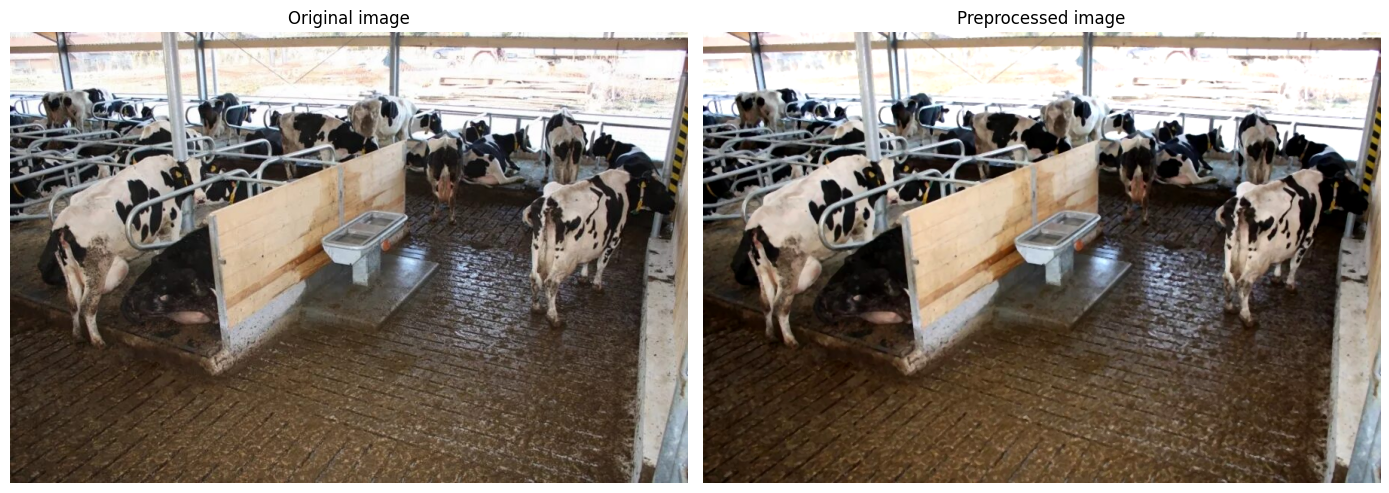

Saved preprocessed image to: /kaggle/working/smart_kitchen_outputs/preprocessed_image.png


In [4]:
#IMAGE_PATH = Path("/kaggle/input/your-dataset/your-image.jpg")
IMAGE_PATH = Path("/kaggle/input/datasets/trainingdatapro/cows-detection-dataset/images/0.png")

# Replace only this line if you already have a PIL image object.
image = Image.open(IMAGE_PATH).convert("RGB")

output_dir = Path("/kaggle/working/smart_kitchen_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

preprocessed_image = preprocess_image(image)
preprocessed_image_path = save_pil_image(preprocessed_image, output_dir / "preprocessed_image.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(image)
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(preprocessed_image)
axes[1].set_title("Preprocessed image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Saved preprocessed image to: {preprocessed_image_path}")


## 3. YOLO で食材検知

モデル読み込みコードは既存ノートブックの記述を維持しています。


,detection_id,label,confidence,class_id,x1,y1,x2,y2,width,height,center_x,center_y
0,0,cow,0.8721,19,672.77,183.17,824.09,394.31,151.32,211.14,748.43,288.74
1,1,cow,0.6998,19,37.47,162.71,248.69,420.47,211.22,257.77,143.08,291.59
2,2,cow,0.6875,19,706.69,105.61,765.21,202.96,58.52,97.35,735.95,154.28
3,3,cow,0.4206,19,442.46,81.62,536.72,163.22,94.25,81.60,489.59,122.42
4,4,cow,0.3993,19,351.47,105.96,466.21,162.26,114.74,56.30,408.84,134.11
5,5,cow,0.3982,19,38.90,76.37,113.39,133.89,74.49,57.52,76.14,105.13
6,6,cow,0.3235,19,525.20,131.20,672.61,254.99,147.41,123.79,598.91,193.09


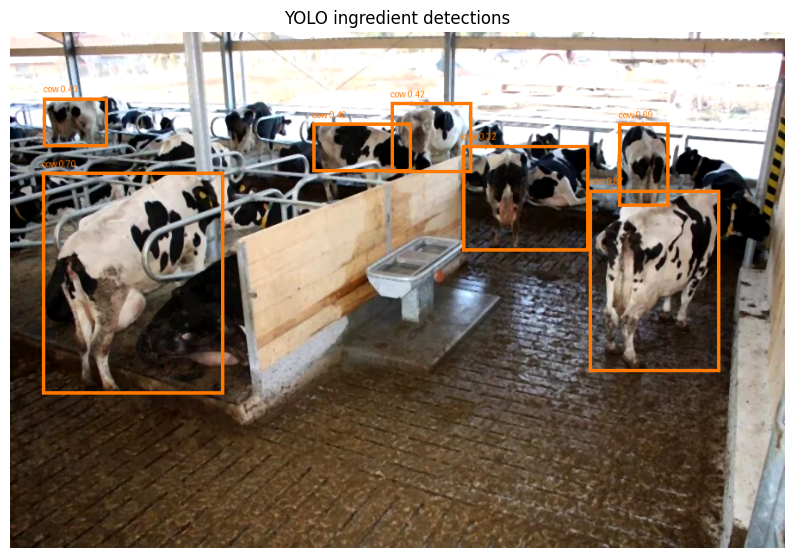

In [5]:
from ultralytics import YOLO

# Load a pretrained YOLO26n model
# 最軽量・最速：エッジ向けのモデル
model = YOLO("yolo26n.pt")

yolo_input_image = preprocessed_image
result = model(yolo_input_image, verbose=False)[0]

yolo_df = build_yolo_detections(result).sort_values("confidence", ascending=False).reset_index(drop=True)
display(yolo_df)

annotated_yolo_image = annotate_yolo_detections(preprocessed_image, yolo_df)
plt.figure(figsize=(10, 10))
plt.imshow(annotated_yolo_image)
plt.title("YOLO ingredient detections")
plt.axis("off")
plt.show()


## 4. PaddleOCR で賞味期限候補を抽出

モデル読み込みコードは既存ノートブックの記述を維持しています。


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-OCRv5_mobile_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_mobile_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Using official model (PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

,ocr_id,rec_text,rec_score,date_candidates,normalized_expiry_date,expiry_signal_strength,bbox_x1,bbox_y1,bbox_x2,bbox_y2


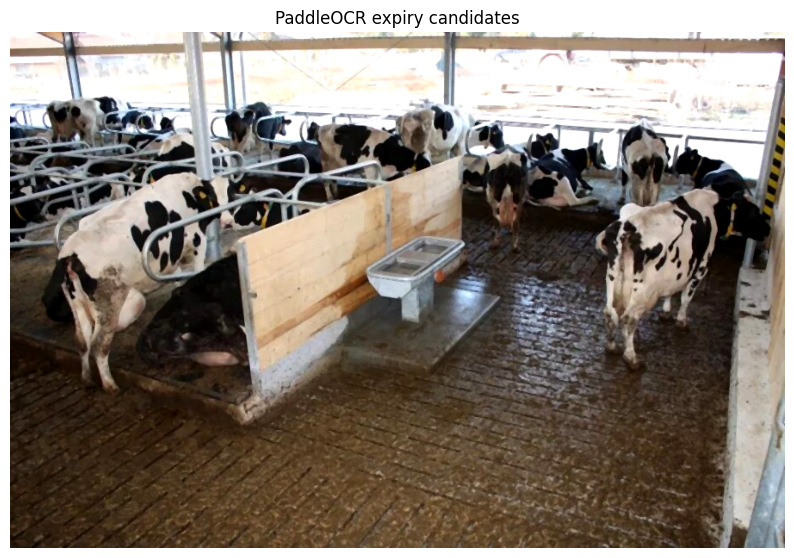

In [6]:
import paddle
import paddleocr
import paddlex
from paddleocr import TextDetection
from paddleocr import TextRecognition

detection = TextDetection(model_name="PP-OCRv5_mobile_det")
recognition = TextRecognition(model_name="PP-OCRv5_mobile_rec")

ocr_df, detection_payloads = run_expiry_ocr_pipeline(
    detection=detection,
    recognition=recognition,
    image=preprocessed_image,
    image_path=preprocessed_image_path,
    save_dir=output_dir / "ocr_pipeline",
)

ocr_df = ocr_df.sort_values(["expiry_signal_strength", "rec_score"], ascending=[False, False]).reset_index(drop=True)
display(ocr_df)

annotated_ocr_image = annotate_ocr_candidates(preprocessed_image, ocr_df)
plt.figure(figsize=(10, 10))
plt.imshow(annotated_ocr_image)
plt.title("PaddleOCR expiry candidates")
plt.axis("off")
plt.show()


## 5. YOLO と OCR の情報を統合 / 6. Supabase 用に整理


In [7]:
merged_df = merge_yolo_and_ocr(
    yolo_df=yolo_df,
    ocr_df=ocr_df,
    image_size=preprocessed_image.size,
)

inventory_df = organize_inventory_records(
    merged_df=merged_df,
    source_image_name=IMAGE_PATH.name,
)

supabase_payload = records_for_supabase(inventory_df)
artifact_paths = write_pipeline_outputs(
    output_dir=output_dir,
    yolo_df=yolo_df,
    ocr_df=ocr_df,
    merged_df=merged_df,
    inventory_df=inventory_df,
    supabase_payload=supabase_payload,
)

display(merged_df)
display(inventory_df)
print(json.dumps(artifact_paths, ensure_ascii=False, indent=2))

WRITE_TO_SUPABASE = False
SUPABASE_TABLE = "inventory_items"

if WRITE_TO_SUPABASE:
    supabase = create_supabase_client(
        url=os.getenv("SUPABASE_URL"),
        key=os.getenv("SUPABASE_SERVICE_ROLE_KEY") or os.getenv("SUPABASE_ANON_KEY"),
    )
    response = upload_inventory_records(
        supabase_client=supabase,
        payload=supabase_payload,
        table_name=SUPABASE_TABLE,
    )
    display(response)
else:
    print("Supabase write skipped. Set WRITE_TO_SUPABASE = True after configuring environment variables.")
    print(json.dumps(supabase_payload[:2], ensure_ascii=False, indent=2))


,detection_id,label,confidence,class_id,x1,y1,x2,y2,width,height,center_x,center_y,ocr_id,ocr_text,ocr_score,ocr_bbox,expiry_date,date_candidates,distance_ratio,match_type
0,0,cow,0.8721,19,672.77,183.17,824.09,394.31,151.32,211.14,748.43,288.74,None,None,None,None,None,[],None,unmatched
1,1,cow,0.6998,19,37.47,162.71,248.69,420.47,211.22,257.77,143.08,291.59,None,None,None,None,None,[],None,unmatched
2,2,cow,0.6875,19,706.69,105.61,765.21,202.96,58.52,97.35,735.95,154.28,None,None,None,None,None,[],None,unmatched
3,3,cow,0.4206,19,442.46,81.62,536.72,163.22,94.25,81.60,489.59,122.42,None,None,None,None,None,[],None,unmatched
4,4,cow,0.3993,19,351.47,105.96,466.21,162.26,114.74,56.30,408.84,134.11,None,None,None,None,None,[],None,unmatched
5,5,cow,0.3982,19,38.90,76.37,113.39,133.89,74.49,57.52,76.14,105.13,None,None,None,None,None,[],None,unmatched
6,6,cow,0.3235,19,525.20,131.20,672.61,254.99,147.41,123.79,598.91,193.09,None,None,None,None,None,[],None,unmatched


,record_id,source_image_name,captured_at,ingredient_name,ingredient_confidence,expiry_text,expiry_date,ingredient_bbox,ocr_bbox,match_type,needs_review
0,0-000,0.png,2026-05-06T07:11:38.757334+00:00,cow,0.8721,None,None,"{'x1': 672.77, 'y1': 183.17, 'x2': 824.09, 'y2': 394.31}",None,unmatched,True
1,0-001,0.png,2026-05-06T07:11:38.757334+00:00,cow,0.6998,None,None,"{'x1': 37.47, 'y1': 162.71, 'x2': 248.69, 'y2': 420.47}",None,unmatched,True
2,0-002,0.png,2026-05-06T07:11:38.757334+00:00,cow,0.6875,None,None,"{'x1': 706.69, 'y1': 105.61, 'x2': 765.21, 'y2': 202.96}",None,unmatched,True
3,0-003,0.png,2026-05-06T07:11:38.757334+00:00,cow,0.4206,None,None,"{'x1': 442.46, 'y1': 81.62, 'x2': 536.72, 'y2': 163.22}",None,unmatched,True
4,0-004,0.png,2026-05-06T07:11:38.757334+00:00,cow,0.3993,None,None,"{'x1': 351.47, 'y1': 105.96, 'x2': 466.21, 'y2': 162.26}",None,unmatched,True
5,0-005,0.png,2026-05-06T07:11:38.757334+00:00,cow,0.3982,None,None,"{'x1': 38.9, 'y1': 76.37, 'x2': 113.39, 'y2': 133.89}",None,unmatched,True
6,0-006,0.png,2026-05-06T07:11:38.757334+00:00,cow,0.3235,None,None,"{'x1': 525.2, 'y1': 131.2, 'x2': 672.61, 'y2': 254.99}",None,unmatched,True


{
  "yolo_csv": "/kaggle/working/smart_kitchen_outputs/yolo_detections.csv",
  "ocr_csv": "/kaggle/working/smart_kitchen_outputs/ocr_expiry_candidates.csv",
  "merged_csv": "/kaggle/working/smart_kitchen_outputs/merged_inventory_view.csv",
  "inventory_csv": "/kaggle/working/smart_kitchen_outputs/inventory_records.csv",
  "supabase_json": "/kaggle/working/smart_kitchen_outputs/supabase_payload.json"
}
Supabase write skipped. Set WRITE_TO_SUPABASE = True after configuring environment variables.
[
  {
    "record_id": "0-000",
    "source_image_name": "0.png",
    "captured_at": "2026-05-06T07:11:38.757334+00:00",
    "ingredient_name": "cow",
    "ingredient_confidence": 0.8721,
    "expiry_text": null,
    "expiry_date": null,
    "ingredient_bbox": {
      "x1": 672.77,
      "y1": 183.17,
      "x2": 824.09,
      "y2": 394.31
    },
    "ocr_bbox": null,
    "match_type": "unmatched",
    "needs_review": true
  },
  {
    "record_id": "0-001",
    "source_image_name": "0.png",
    "